In [21]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import TypedDict, Literal

In [22]:
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=1.0)

In [23]:
class review_category_schema(BaseModel):
    category: Literal["Positive","Negative"] = Field(description= "Categorize the given review into positiive and negative")

class diagnosis_schema(BaseModel):
    issue_type: Literal["UX","Performance","Bug", "Support", "Other"] = Field(description="The category of issue mentioned in the review") 
    tone:Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [24]:
model_review = model.with_structured_output(review_category_schema)
model_diagnosis = model.with_structured_output(diagnosis_schema)

In [25]:
class reviewstate(TypedDict):
    review: str
    category: Literal["Positive", "Negative"]
    diagnosis: dict
    response: str

In [26]:
def check_category(state: reviewstate)-> Literal['positive_response','run_diagnosis']:
    if state['category'] == 'Positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [27]:
def find_category(state: reviewstate):
    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    category = model_review.invoke(prompt).category

    return {'category': category}

In [28]:
def positive_response(state: reviewstate):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content
    return {'response': response}

In [29]:
def run_diagnosis(state: reviewstate):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    diagnosis = model_diagnosis.invoke(prompt)
    return {'diagnosis': diagnosis.model_dump()}

def negative_response(state: reviewstate):
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content
    return {"response": response}

In [30]:
graph = StateGraph(reviewstate)

graph.add_node("find_category", find_category)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)
graph.add_node("positive_response", positive_response)

graph.add_edge(START, 'find_category')
graph.add_conditional_edges('find_category', check_category)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()


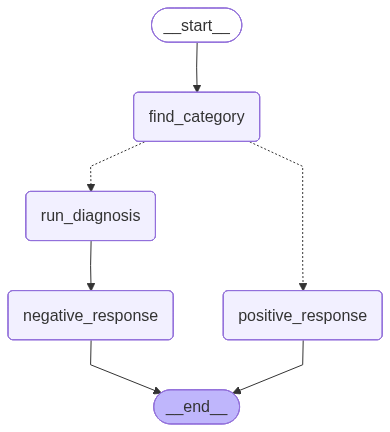

In [31]:
workflow

In [32]:
inital_state = {'review': 'I have been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.'}
final_state = workflow.invoke(inital_state)
print(final_state)

{'review': 'I have been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.', 'category': 'Negative', 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'}, 'response': 'I understand you\'re experiencing a bug and are feeling frustrated, especially with the high urgency. I\'m really sorry to hear that this is causing you trouble.\n\nI want to assure you that we\'re taking this seriously and are committed to helping you resolve this as quickly as possible.\n\nTo help me pinpoint the issue and get it fixed for you, could you please provide a little more detail? Specifically, if you could tell me:\n\n*   **What is the exact bug you\'re encountering?** (e.g., "The save button isn\'t working," "I\'m getting an error message when I try to log in," "The system is crashing when I do X.")\n*   **When did th

In [33]:
print(final_state['category'])

Negative


In [35]:
print(final_state['diagnosis'])

print("-------------------")
print(final_state['response'])

{'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'}
-------------------
I understand you're experiencing a bug and are feeling frustrated, especially with the high urgency. I'm really sorry to hear that this is causing you trouble.

I want to assure you that we're taking this seriously and are committed to helping you resolve this as quickly as possible.

To help me pinpoint the issue and get it fixed for you, could you please provide a little more detail? Specifically, if you could tell me:

*   **What is the exact bug you're encountering?** (e.g., "The save button isn't working," "I'm getting an error message when I try to log in," "The system is crashing when I do X.")
*   **When did this bug start happening?**
*   **Are there any specific steps you take that consistently trigger the bug?**
*   **Are you seeing any error messages? If so, what do they say?**
*   **What device and browser (if applicable) are you using?**

The more information you can give us, the faster we 